In [34]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mercari_df = pd.read_csv('../../data/mercari_train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


In [35]:
# ============================================================
# [Cell 2] 데이터 요약 정보(Info) 및 각 컬럼별 결측치 개수 확인
# ============================================================
print("=== 데이터 요약 정보 ===")
mercari_df.info()

print("\n=== 컬럼별 결측치(NaN) 개수 ===")
print(mercari_df.isnull().sum())

=== 데이터 요약 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  str    
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  str    
 4   brand_name         849853 non-null   str    
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 90.5 MB

=== 컬럼별 결측치(NaN) 개수 ===
train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64


In [36]:
# ============================================================
# [Cell 3] 원본 가격(Target) 분리 및 0원 데이터 확인
# ============================================================
# 타깃 변수 분리
y_labels_org = mercari_df['price']

# 가격이 0원인 건수 확인 (로그 변환 시 마이너스 무한대 방지를 위해 체크)
zero_count = (y_labels_org == 0).sum()
print(f"가격이 0원인 행의 수: {zero_count}건")

# 가격 기초 통계량 확인
print("\n=== 원본 가격 기술통계 ===")
print(y_labels_org.describe())

가격이 0원인 행의 수: 874건

=== 원본 가격 기술통계 ===
count    1.482535e+06
mean     2.673752e+01
std      3.858607e+01
min      0.000000e+00
25%      1.000000e+01
50%      1.700000e+01
75%      2.900000e+01
max      2.009000e+03
Name: price, dtype: float64


In [37]:
# ============================================================
# [Cell 3-1] 중복 데이터 확인 및 제거
# ============================================================
# train_id는 고유 번호이므로 제외하고 실제 상품 내용 컬럼들을 기준으로 중복 체크
feature_cols = ['name', 'item_condition_id', 'category_name', 'brand_name', 'shipping', 'item_description', 'price']

# 중복 행 개수 확인
duplicate_count = mercari_df.duplicated(subset=feature_cols).sum()
print(f"제거 전 중복 데이터 개수: {duplicate_count}건")

# 중복 데이터 제거 (첫 번째 행만 유지하고 나머지 삭제 후 인덱스 재정렬)
if duplicate_count > 0:
    mercari_df = mercari_df.drop_duplicates(subset=feature_cols, keep='first').reset_index(drop=True)
    print("중복 데이터 제거 완료! 현재 데이터 크기:", mercari_df.shape)

제거 전 중복 데이터 개수: 49건
중복 데이터 제거 완료! 현재 데이터 크기: (1482486, 8)


In [38]:
# ============================================================
# [Cell 3-2] 가격이 0원(무료/이상치)인 행 제거
# ============================================================
# 1. 0원 제거
mercari_df = mercari_df[mercari_df['price'] > 0]

# 2. 2000달러 이상 이상치 제거 (팀 공통 규칙)
mercari_df = mercari_df[mercari_df['price'] < 2000]

# 3. 모델 학습에 불필요한 train_id 컬럼 제거
if 'train_id' in mercari_df.columns:
    mercari_df.drop(columns='train_id', inplace=True)

# 4. 중복 제거 및 인덱스 재정렬
mercari_df = mercari_df.drop_duplicates().reset_index(drop=True)
print(f"이상치 및 ID 제거 완료! 최종 학습용 데이터 크기: {mercari_df.shape}")

이상치 및 ID 제거 완료! 최종 학습용 데이터 크기: (1481603, 7)


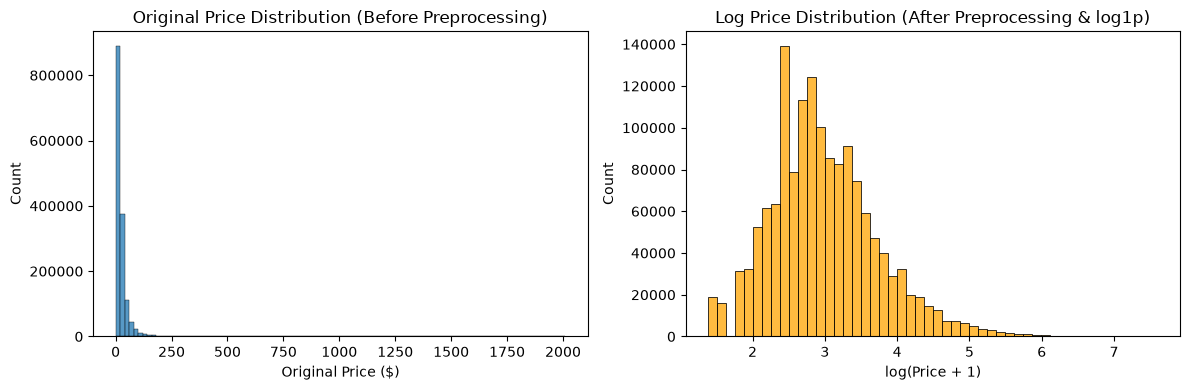

In [39]:
# ============================================================
# [Cell 4] log1p 로그 변환 적용 및 왜도(Skewness) 완화 시각화
# ============================================================
# 1. 정제된 mercari_df의 price 컬럼에 log1p 변환 적용 (모델 학습용)
mercari_df['price'] = np.log1p(mercari_df['price'])

# 2. EDA용: 완전 원본(전처리 전) vs 정제+로그변환(전처리 후) 비교 시각화
plt.figure(figsize=(12, 4))

# [전처리 전] 데이터 로드 직후의 완전 원본 가격 분포 (0원 포함, 중복 포함)
plt.subplot(1, 2, 1)
sns.histplot(y_labels_org, bins=100)
plt.title('Original Price Distribution (Before Preprocessing)')
plt.xlabel('Original Price ($)')

# [전처리 후] 중복/0원 제거 및 log1p 변환까지 완료된 가격 분포
plt.subplot(1, 2, 2)
sns.histplot(mercari_df['price'], bins=50, color='orange')
plt.title('Log Price Distribution (After Preprocessing & log1p)')
plt.xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# [Cell 5] 주요 범주형 피처의 고유값 빈도 확인
# ============================================================
# shipping: 0(구매자 부담), 1(판매자 무료배송)
print("=== Shipping 값 유형 ===")
print(mercari_df['shipping'].value_counts())

# item_condition_id: 1(새것) ~ 5(낡음)
print("\n=== Item Condition ID 값 유형 ===")
print(mercari_df['item_condition_id'].value_counts())

=== Shipping 값 유형 ===
shipping
0    818865
1    662738
Name: count, dtype: int64

=== Item Condition ID 값 유형 ===
item_condition_id
1    640193
3    431891
2    375192
4     31945
5      2382
Name: count, dtype: int64


/var/folders/k5/016tl75j769dp2f18hmv5rvw0000gn/T/ipykernel_68619/114671057.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='shipping', y='price', data=mercari_df, showfliers=False, palette='Set2')
/var/folders/k5/016tl75j769dp2f18hmv5rvw0000gn/T/ipykernel_68619/114671057.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='item_condition_id', y='price', data=mercari_df, showfliers=False, palette='Pastel1')


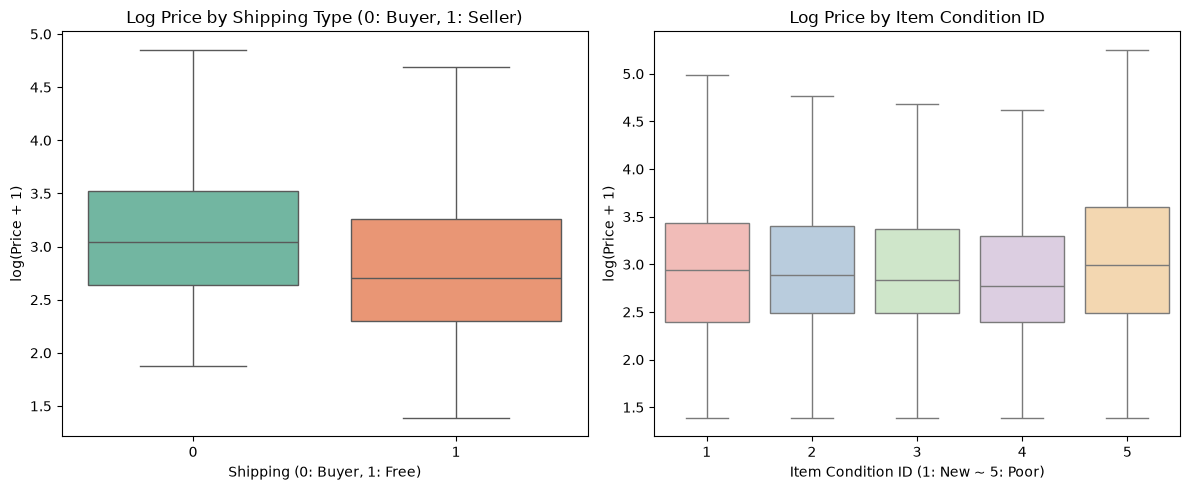

In [41]:
# ============================================================
# [시각화 1] 배송비 여부 및 상품 상태별 로그 가격 분포 (Boxplot)
# ============================================================
plt.figure(figsize=(12, 5))

# 1. 배송비 부담 여부별 가격 분포
plt.subplot(1, 2, 1)
sns.boxplot(x='shipping', y='price', data=mercari_df, showfliers=False, palette='Set2')
plt.title('Log Price by Shipping Type (0: Buyer, 1: Seller)')
plt.xlabel('Shipping (0: Buyer, 1: Free)')
plt.ylabel('log(Price + 1)')

# 2. 상품 상태 등급별 가격 분포
plt.subplot(1, 2, 2)
sns.boxplot(x='item_condition_id', y='price', data=mercari_df, showfliers=False, palette='Pastel1')
plt.title('Log Price by Item Condition ID')
plt.xlabel('Item Condition ID (1: New ~ 5: Poor)')
plt.ylabel('log(Price + 1)')

plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# [Cell 6] 카테고리 분할 (대/중/소 3단계)
# ============================================================
# 슬래시(/) 기준으로 분할하되, 결측치(NaN)일 경우 예외 처리
def split_cat(category_name):
    try:
        return category_name.split('/')
    except:
        return ['Other_Null', 'Other_Null', 'Other_Null']

# 대, 중, 소 3개 컬럼으로 분리 할당
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
    zip(*mercari_df['category_name'].apply(lambda x: split_cat(x)))

print("대분류 고유값 개수:", mercari_df['cat_dae'].nunique())
print("중분류 고유값 개수:", mercari_df['cat_jung'].nunique())
print("소분류 고유값 개수:", mercari_df['cat_so'].nunique())

대분류 고유값 개수: 11
중분류 고유값 개수: 114
소분류 고유값 개수: 871


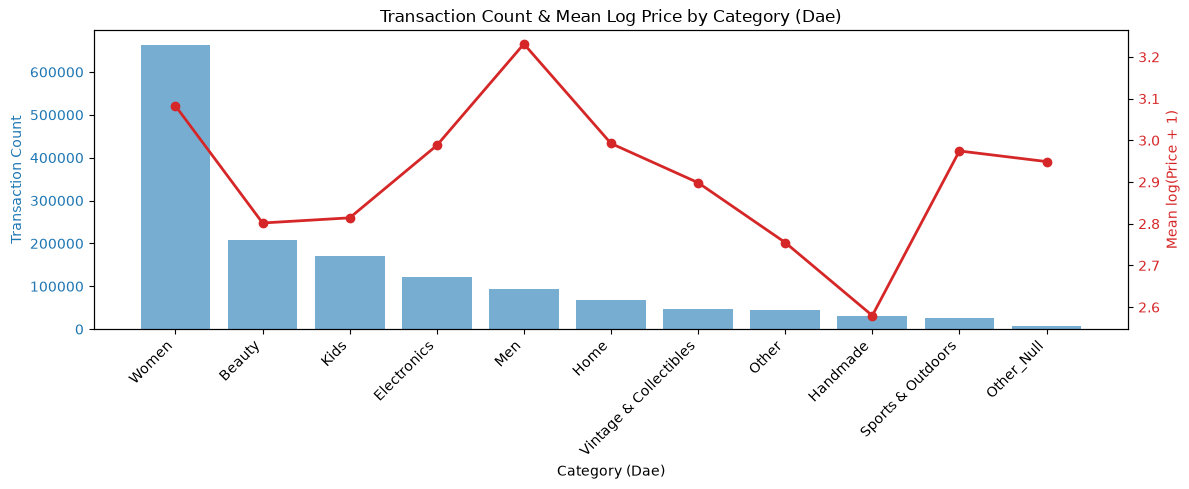

In [43]:
# ============================================================
# [시각화 2] 대분류 카테고리별 건수 및 평균 가격 비교
# ============================================================
cat_stats = mercari_df.groupby('cat_dae')['price'].agg(['count', 'mean']).sort_values(by='count', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 5))

# 1. 거래 건수 (막대 그래프)
color = 'tab:blue'
ax1.set_xlabel('Category (Dae)')
ax1.set_ylabel('Transaction Count', color=color)
bars = ax1.bar(cat_stats.index, cat_stats['count'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45, ha='right')

# 2. 평균 로그 가격 (꺾은선 그래프)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Mean log(Price + 1)', color=color)
ax2.plot(cat_stats.index, cat_stats['mean'], color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Transaction Count & Mean Log Price by Category (Dae)')
plt.tight_layout()
plt.show()

In [44]:
# [Cell 7] 결측치(NaN) 대체 및 타깃 벡터 갱신
# ============================================================
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')

# 필터링 및 전처리가 완료된 정제된 타깃값 동기화
y_train_target = mercari_df['price']

print("=== 결측치 대체 후 잔여 NaN 개수 ===")
print(mercari_df.isnull().sum())

=== 결측치 대체 후 잔여 NaN 개수 ===
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
cat_dae              0
cat_jung             0
cat_so               0
dtype: int64


In [ ]:
# ============================================================
# [Cell 7-1] item_description 텍스트 클리닝 및 전처리
# ============================================================
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# NLTK 불용어 및 토크나이저 리소스 다운로드
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# 1. 텍스트 클리닝 함수 (소문자화 및 영문/숫자 외 제거)
def text_cleaning(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# 2. 불용어 세팅 (부정어 유지 및 [rm] 마스킹 노이즈 제거)
stop_words = set(stopwords.words('english'))

# 제거하면 안 되는 핵심 부정어 목록
negative_words = {'no', 'not', 'nor', 'never', 'without'}

# 마스킹 후 남은 노이즈 토큰 'rm'을 불용어로 추가 (팀 공통)
stop_words = (stop_words | {'rm'}) - negative_words

# 3. 통합 전처리 함수 (토큰화 -> 불용어 제거 -> 공백 연결 문자열 반환)
def preprocess_text(text):
    text = text_cleaning(text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# 4. 전처리 함수 적용
print("item_description 텍스트 전처리 진행 중...")
mercari_df['item_description'] = mercari_df['item_description'].apply(preprocess_text)
print("전처리 완료 상위 3건 미리보기:")
print(mercari_df['item_description'].head(3))

item_description 텍스트 전처리 진행 중...
전처리 완료 상위 3건 미리보기:
0                                   no description yet
1    keyboard great condition works like came box p...
2    adorable top hint lace key hole back pale pink...
Name: item_description, dtype: str


In [46]:
# ============================================================
# [Cell 8] 피처 벡터화 & 원-핫 인코딩 (희소 행렬 변환)
# ============================================================
from sklearn.preprocessing import LabelBinarizer

# 1. 텍스트 벡터화
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df['name'])

tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

# 2. 범주형 원-핫 인코딩 (희소 행렬 형식 유지)
lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])

lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])

lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_cat_dae.fit_transform(mercari_df['cat_dae'])

lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])

lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

print(f"X_name shape: {X_name.shape}, X_descp shape: {X_descp.shape}")
print(f"X_brand shape: {X_brand.shape}, X_cat_so shape: {X_cat_so.shape}")

X_name shape: (1481603, 105722), X_descp shape: (1481603, 50000)
X_brand shape: (1481603, 4808), X_cat_so shape: (1481603, 871)


/var/folders/k5/016tl75j769dp2f18hmv5rvw0000gn/T/ipykernel_68619/2377218718.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette='viridis')


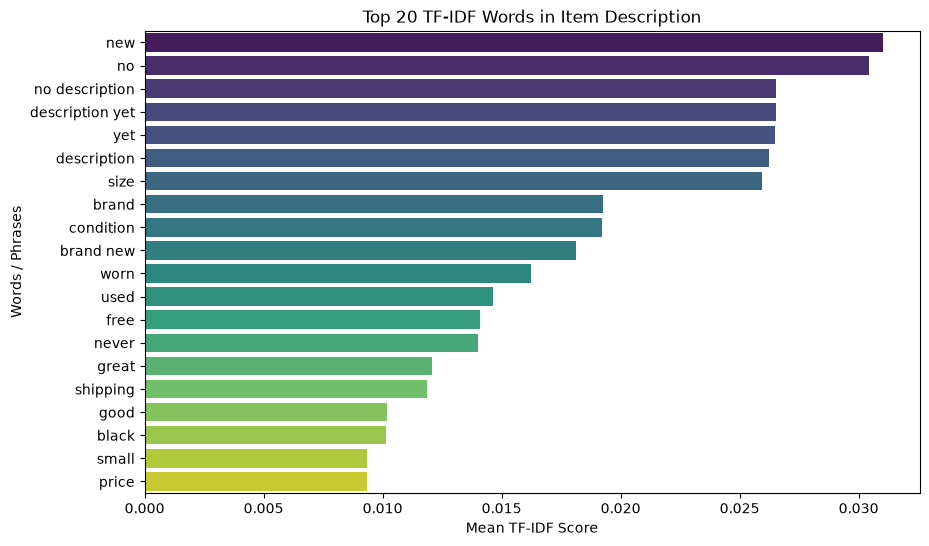

In [47]:
# ============================================================
# [시각화 3] Item Description 상위 중요 TF-IDF 단어 Top 20
# ============================================================
# TF-IDF 점수 합산 기준 상위 20개 단어 추출
tfidf_scores = np.asarray(X_descp.mean(axis=0)).ravel()
top_words_idx = tfidf_scores.argsort()[::-1][:20]
top_words = [tfidf_descp.get_feature_names_out()[i] for i in top_words_idx]
top_scores = tfidf_scores[top_words_idx]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_scores, y=top_words, palette='viridis')
plt.title('Top 20 TF-IDF Words in Item Description')
plt.xlabel('Mean TF-IDF Score')
plt.ylabel('Words / Phrases')
plt.show()

In [48]:
# ============================================================
# [Cell 9] 평가지표(RMSLE) 및 학습/예측 함수 정의
# ============================================================
from scipy.sparse import hstack
import gc

def rmsle(y, y_pred):
    return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))

def evaluate_org_price(y_test, preds):
    preds_expm = np.expm1(preds)
    y_test_expm = np.expm1(y_test)
    return rmsle(y_test_expm, preds_expm)


def model_train_predict(model, matrix_list):
    # 1. 전달받은 희소 행렬들을 가로로 결합하고 CSR 압축 포맷으로 변환
    X = hstack(matrix_list).tocsr()
    
    # 2. 80%는 훈련용(Train), 20%는 평가용(Test)으로 분할 (결과 재현을 위해 random_state 고정)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_train_target, test_size=0.2, random_state=42
    )
    
    # 3. 모델 학습 및 테스트 세트 예측
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # 4. 사용이 끝난 거대 행렬들을 메모리에서 즉시 강제 삭제
    del X, X_train, X_test, y_train
    gc.collect()
    
    # 5. 예측 결과와 실제 정답을 반환
    return preds, y_test

In [ ]:
# ============================================================
# [Cell 10] Ridge 선형 회귀 모델 학습 및 평가
# ============================================================
from sklearn.linear_model import Ridge

# solver='lsqr': 희소 행렬 연산에 최적화된 최소제곱법 알고리즘
linear_model = Ridge(solver="lsqr", fit_intercept=False)

# 1. 상품 설명글(X_descp)을 제외한 피처 조합
matrix_list_no_descp = (X_name, X_brand, X_item_cond_id,
                        X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
preds_no_descp, y_test = model_train_predict(linear_model, matrix_list_no_descp)
print("Item Description 제외 시 Ridge RMSLE:", evaluate_org_price(y_test, preds_no_descp))

# 2. 상품 설명글(X_descp)을 포함한 전체 피처 조합
matrix_list_with_descp = (X_descp, X_name, X_brand, X_item_cond_id,
                          X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
preds_with_descp, y_test = model_train_predict(linear_model, matrix_list_with_descp)
print("Item Description 포함 시 Ridge RMSLE:", evaluate_org_price(y_test, preds_with_descp))

# # ============================================================
# [Cell 11] LightGBM 회귀 모델 학습 및 평가
# ============================================================
from lightgbm import LGBMRegressor

# 대용량 희소 행렬에 맞춰 트리 깊이와 리프 노드 수 설정
lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=42)

# 설명글을 포함한 전체 피처로 학습
preds_lgbm, y_test = model_train_predict(lgbm_model, matrix_list_with_descp)
print("LightGBM RMSLE:", evaluate_org_price(y_test, preds_lgbm))

# Item Description 제외 시 Ridge RMSLE: 0.49481616425603453
# Item Description 포함 시 Ridge RMSLE: 0.46183068696661567

Item Description 제외 시 Ridge RMSLE: 0.49481616425603453
Item Description 포함 시 Ridge RMSLE: 0.46183068696661567


In [ ]:
# ============================================================
# [Cell 11] LightGBM 회귀 모델 학습 및 평가
# ============================================================
from lightgbm import LGBMRegressor

# 대용량 희소 행렬에 맞춰 트리 깊이와 리프 노드 수 설정
lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=42)

# 설명글을 포함한 전체 피처로 학습
preds_lgbm, y_test = model_train_predict(lgbm_model, matrix_list_with_descp)
print("LightGBM RMSLE:", evaluate_org_price(y_test, preds_lgbm))

# LightGBM RMSLE: 0.44977592562719015

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 123.327429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1035270
[LightGBM] [Info] Number of data points in the train set: 1185282, number of used features: 65380
[LightGBM] [Info] Start training from score 2.980810
LightGBM RMSLE: 0.44977592562719015


In [ ]:
# ============================================================
# [Cell 12] Ridge와 LightGBM의 앙상블 예측 평가
# ============================================================
# Ridge(0.45) + LightGBM(0.55) 비율로 결합
preds_ensemble = preds_with_descp * 0.45 + preds_lgbm * 0.55
print("Ridge + LightGBM 앙상블 RMSLE:", evaluate_org_price(y_test, preds_ensemble))

# Ridge + LightGBM 앙상블 RMSLE: 0.4388242416875396

Ridge + LightGBM 앙상블 RMSLE: 0.4388242416875396


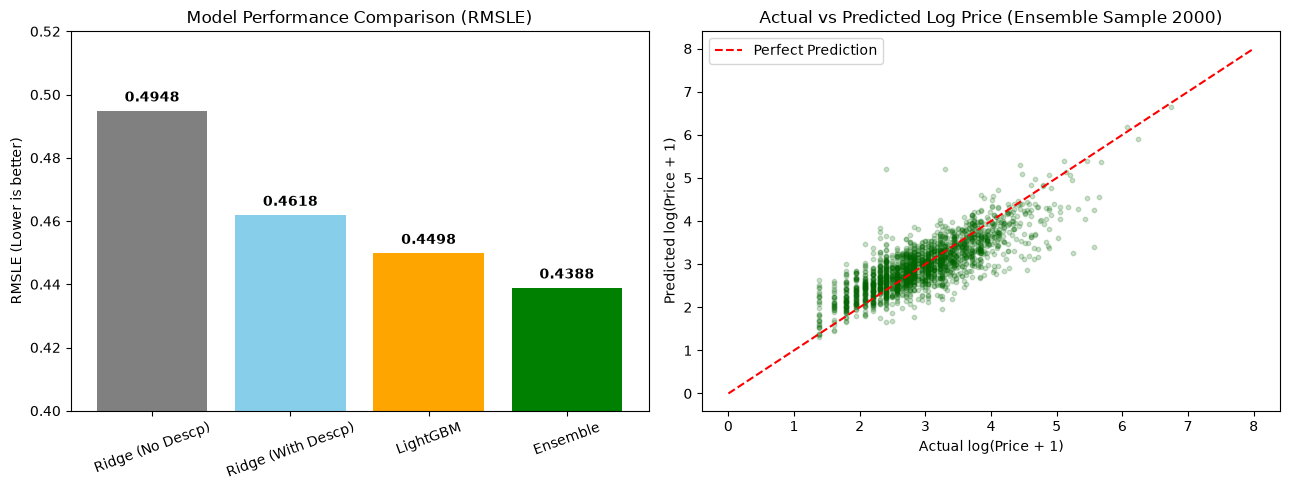

In [52]:
# ============================================================
# [시각화 4] 모델별 RMSLE 성능 비교 및 최종 예측 산점도
# ============================================================
plt.figure(figsize=(13, 5))

# 1. 모델별 RMSLE 비교 막대그래프
plt.subplot(1, 2, 1)
model_names = ['Ridge (No Descp)', 'Ridge (With Descp)', 'LightGBM', 'Ensemble']
rmsle_scores = [
    evaluate_org_price(y_test, preds_no_descp),
    evaluate_org_price(y_test, preds_with_descp),
    evaluate_org_price(y_test, preds_lgbm),
    evaluate_org_price(y_test, preds_ensemble)
]
bars = plt.bar(model_names, rmsle_scores, color=['gray', 'skyblue', 'orange', 'green'])
plt.title('Model Performance Comparison (RMSLE)')
plt.ylabel('RMSLE (Lower is better)')
plt.ylim(0.40, 0.52)
plt.xticks(rotation=20)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.003, f"{yval:.4f}", ha='center', fontweight='bold')

# 2. 앙상블 모델의 실제값 vs 예측값 산점도 (샘플 2,000건 추출)
plt.subplot(1, 2, 2)
sample_idx = np.random.choice(len(y_test), 2000, replace=False)
plt.scatter(y_test.iloc[sample_idx] if hasattr(y_test, 'iloc') else y_test[sample_idx], 
            preds_ensemble[sample_idx], alpha=0.2, color='darkgreen', s=10)
plt.plot([0, 8], [0, 8], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Actual vs Predicted Log Price (Ensemble Sample 2000)')
plt.xlabel('Actual log(Price + 1)')
plt.ylabel('Predicted log(Price + 1)')
plt.legend()

plt.tight_layout()
plt.show()